In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import qmc
import numpy as np

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
alpha = .1

In [5]:
class FCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        )

    def forward(self, x, t):
        all_data = torch.cat([x, t], dim=1)
        return self.net(all_data)
    

In [6]:
def physics_loss(model, x, t, alpha):

    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    first_derivs = torch.autograd.grad(u, [x, t], torch.ones_like(u), create_graph=True)

    dudx = first_derivs[0]
    dudt = first_derivs[1]

    dudxx = torch.autograd.grad(dudx, x, torch.ones_like(dudx), create_graph=True)[0]

    residual = dudt - alpha * dudxx 
    return torch.mean(residual**2)


In [7]:
def lhs(n, dimensions):

    sampler = qmc.LatinHypercube(dimensions)

    points = sampler.random(n)

    return torch.tensor(points, dtype=torch.float32)

In [8]:
N_f = 2000

points = lhs(N_f, 2)

x_f = points[:, 0:1].clone().detach().requires_grad_(True)
t_f = points[:, 1:2].clone().detach().requires_grad_(True)

In [9]:
N_ic = 200

x_ic = lhs(N_ic, 1)

t_ic = torch.zeros_like(x_ic)

In [10]:
N_bc = 200

t_bc = lhs(N_bc, 1)

x_bc_left = torch.zeros_like(t_bc)
x_bc_right = torch.ones_like(t_bc)

In [11]:
model = FCN().to(device)
optimizer = optim.Adam(model.parameters(), lr = .001)


In [12]:
def ic_loss():

    u_pred = model(x_ic, t_ic)

    u_true = torch.sin(torch.pi * x_ic)

    return torch.mean((u_pred - u_true) ** 2)

In [13]:
def bc_loss():

    u_left = model(x_bc_left, t_bc)

    u_right = model(x_bc_right, t_bc)

    loss_left = torch.mean(u_left ** 2)
    loss_right = torch.mean(u_right ** 2)

    return loss_left + loss_right

In [14]:
epochs = 2000

for epoch in range(epochs):

    optimizer.zero_grad()

    loss_physics = physics_loss(model, x_f, t_f, alpha)
    loss_initial = ic_loss()
    loss_boundary = bc_loss()

    loss = loss_physics + loss_boundary + loss_initial
    
    loss.backward()

    optimizer.step()

    if (epoch+1) % 500 == 0:

        print(
            f"Epoch {(epoch+1):5d} | "
            f"Total: {loss.item():.6f} | "
            f"Physics: {loss_physics.item():.6f} | "
            f"IC: {loss_initial.item():.6f} | "
            f"BC: {loss_boundary.item():.6f}"
        )

Epoch   500 | Total: 0.203925 | Physics: 0.013485 | IC: 0.142003 | BC: 0.048437
Epoch  1000 | Total: 0.005732 | Physics: 0.003644 | IC: 0.001064 | BC: 0.001024
Epoch  1500 | Total: 0.000710 | Physics: 0.000598 | IC: 0.000023 | BC: 0.000089
Epoch  2000 | Total: 0.000366 | Physics: 0.000291 | IC: 0.000004 | BC: 0.000072


In [15]:
sample_x = torch.tensor([[1.0]])
sample_t = torch.tensor([[0.0]])
model(sample_x, sample_t)

tensor([[0.0064]], grad_fn=<AddmmBackward0>)

In [16]:
torch.exp(-alpha * torch.pi**2 * sample_t) * torch.sin(torch.pi * sample_x)

tensor([[-8.7423e-08]])

In [17]:
print("alpha:", alpha)
print("x:", sample_x)
print("t:", sample_t)

a = torch.exp(-alpha * torch.pi**2 * sample_t)
b = torch.sin(torch.pi * sample_x)

print("exponential:", a)
print("sine:", b)
print("product:", a * b)

alpha: 0.1
x: tensor([[1.]])
t: tensor([[0.]])
exponential: tensor([[1.]])
sine: tensor([[-8.7423e-08]])
product: tensor([[-8.7423e-08]])


In [18]:
physics_loss(model, sample_x, sample_t, alpha)

tensor(0.0153, grad_fn=<MeanBackward0>)

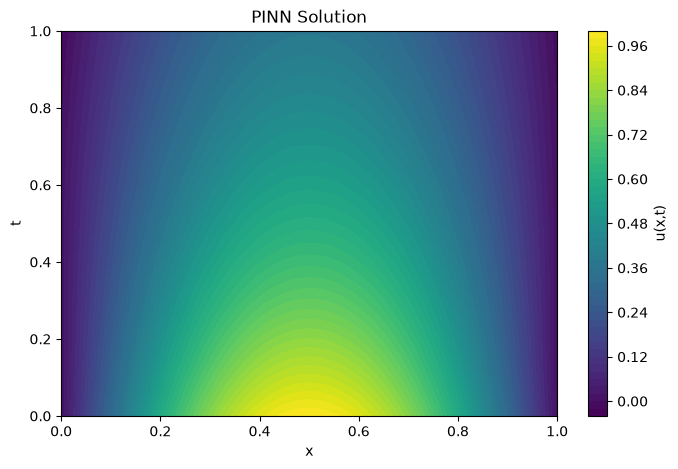

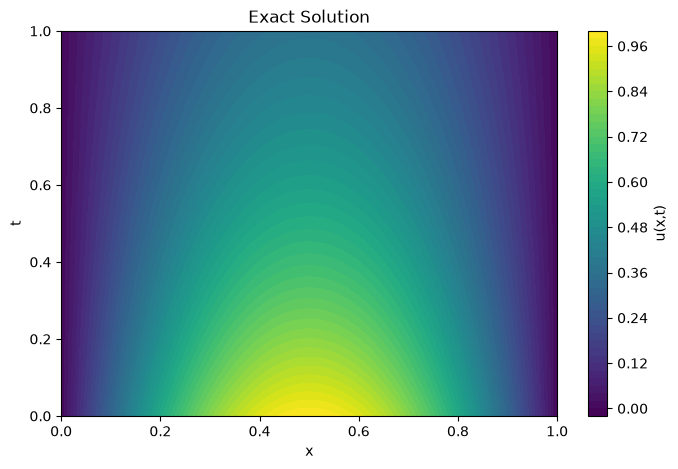

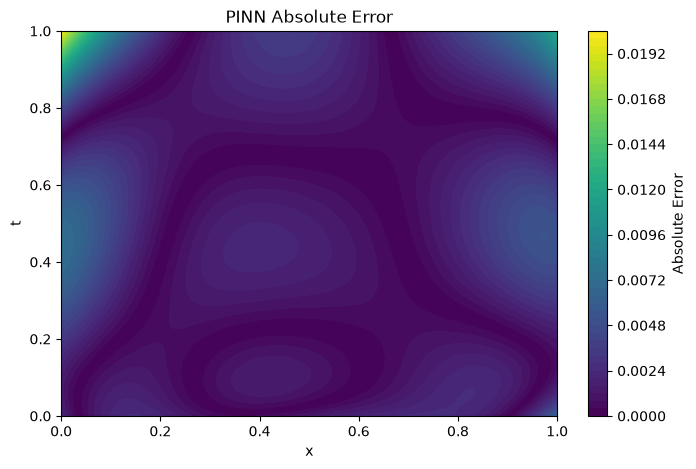

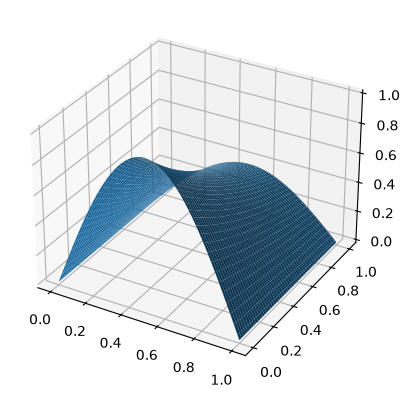

In [32]:

x_plot = torch.linspace(0, 1, 100)
t_plot = torch.linspace(0, 1, 100)

X, T = torch.meshgrid(
    x_plot,
    t_plot,
    indexing="xy"
)

x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)


with torch.no_grad():
    u_pred = model(x_flat, t_flat)

u_pred = u_pred.reshape(100, 100)


u_actual = (
    torch.exp(-alpha * torch.pi**2 * T)
    * torch.sin(torch.pi * X)
)


plt.figure(figsize=(8, 5))

plt.contourf(
    X.numpy(),
    T.numpy(),
    u_pred.numpy(),
    levels=50
)

plt.colorbar(label="u(x,t)")

plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution")

plt.show()

plt.figure(figsize=(8, 5))

plt.contourf(
    X.numpy(),
    T.numpy(),
    u_actual.numpy(),
    levels=50
)

plt.colorbar(label="u(x,t)")

plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Solution")

plt.show()


error = torch.abs(u_pred - u_actual)

plt.figure(figsize=(8, 5))

plt.contourf(
    X.numpy(),
    T.numpy(),
    error.numpy(),
    levels=50
)

plt.colorbar(label="Absolute Error")

plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Absolute Error")

plt.show()

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_surface(X,T,u_actual)